<a href="https://colab.research.google.com/github/bemourasilva-png/estatistica-students-performance/blob/main/analise_students_performance_final_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Importação e exploração do DataSet

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
url = 'https://raw.githubusercontent.com/bemourasilva-png/estatistica-students-performance/main/data/StudentsPerformance.csv'
base = pd.read_csv(url)
base.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [2]:
base.shape

(1000, 8)

In [3]:
base.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [4]:
base.isnull().sum()

,0
gender,0
race/ethnicity,0
parental level of education,0
lunch,0
test preparation course,0
math score,0
reading score,0
writing score,0


In [5]:
base.describe().round(2)

,math score,reading score,writing score
count,1000.00,1000.00,1000.00
mean,66.09,69.17,68.05
std,15.16,14.60,15.20
min,0.00,17.00,10.00
25%,57.00,59.00,57.75
50%,66.00,70.00,69.00
75%,77.00,79.00,79.00
max,100.00,100.00,100.00


In [6]:
categoricas = ['gender', 'race/ethnicity', 'parental level of education',
               'lunch', 'test preparation course']
for i in categoricas:
 agrupado = base.groupby([i]).size()
 print(agrupado)
 print('-'*40)

gender
female    518
male      482
dtype: int64
----------------------------------------
race/ethnicity
group A     89
group B    190
group C    319
group D    262
group E    140
dtype: int64
----------------------------------------
parental level of education
associate's degree    222
bachelor's degree     118
high school           196
master's degree        59
some college          226
some high school      179
dtype: int64
----------------------------------------
lunch
free/reduced    355
standard        645
dtype: int64
----------------------------------------
test preparation course
completed    358
none         642
dtype: int64
----------------------------------------


Conclusões:
*   O data set possui 1000 registros para 8 variaveis, sendo 5 categóricas - gênero, raça/etnia, nivel de educação dos pais, almoço e curso preparatório - e 3 numéricas - nota de matemática, nota de leitura e nota de escrita;
*   Não tem possui valores nulos;


*   As notas variam de 0 a 100







EDA e Amostragem

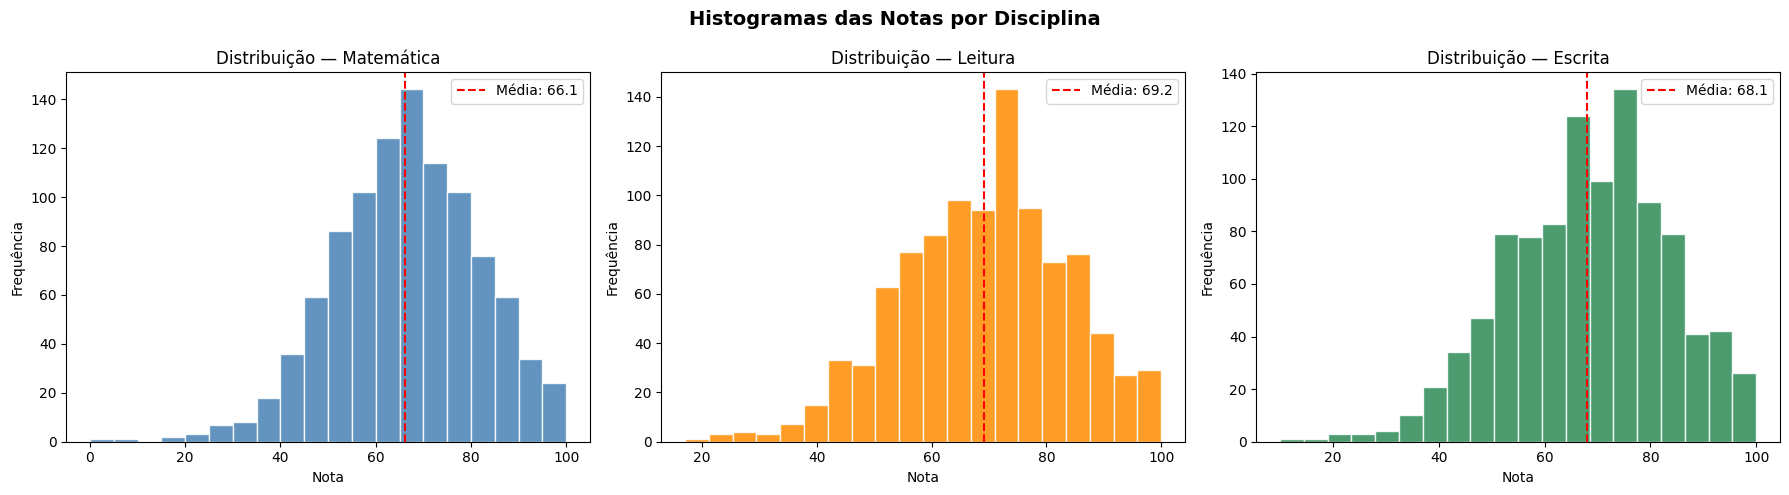

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

disciplinas = ['math score', 'reading score', 'writing score']
titulos = ['Matemática', 'Leitura', 'Escrita']
cores = ['steelblue', 'darkorange', 'seagreen']

for i, (col, titulo, cor) in enumerate(zip(disciplinas, titulos, cores)):
    axes[i].hist(base[col], bins=20, color=cor, edgecolor='white', alpha=0.85)
    axes[i].set_title(f'Distribuição — {titulo}')
    axes[i].set_xlabel('Nota')
    axes[i].set_ylabel('Frequência')
    axes[i].axvline(base[col].mean(), color='red', linestyle='--', label=f'Média: {base[col].mean():.1f}')
    axes[i].legend()

plt.suptitle('Histogramas das Notas por Disciplina', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [8]:
amostra_simples = base.sample(frac=0.1, random_state=42)
print(f"Tamanho da amostra: {len(amostra_simples)}")
print(f"\nMédia das notas na amostra:")
print(amostra_simples[disciplinas].mean().round(2))

Tamanho da amostra: 100

Média das notas na amostra:
math score       63.95
reading score    67.29
writing score    66.03
dtype: float64


/tmp/ipykernel_3759/3583901382.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=base, x='gender', y=col, palette='muted', ax=axes[i])
/tmp/ipykernel_3759/3583901382.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=base, x='gender', y=col, palette='muted', ax=axes[i])
/tmp/ipykernel_3759/3583901382.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=base, x='gender', y=col, palette='muted', ax=axes[i])


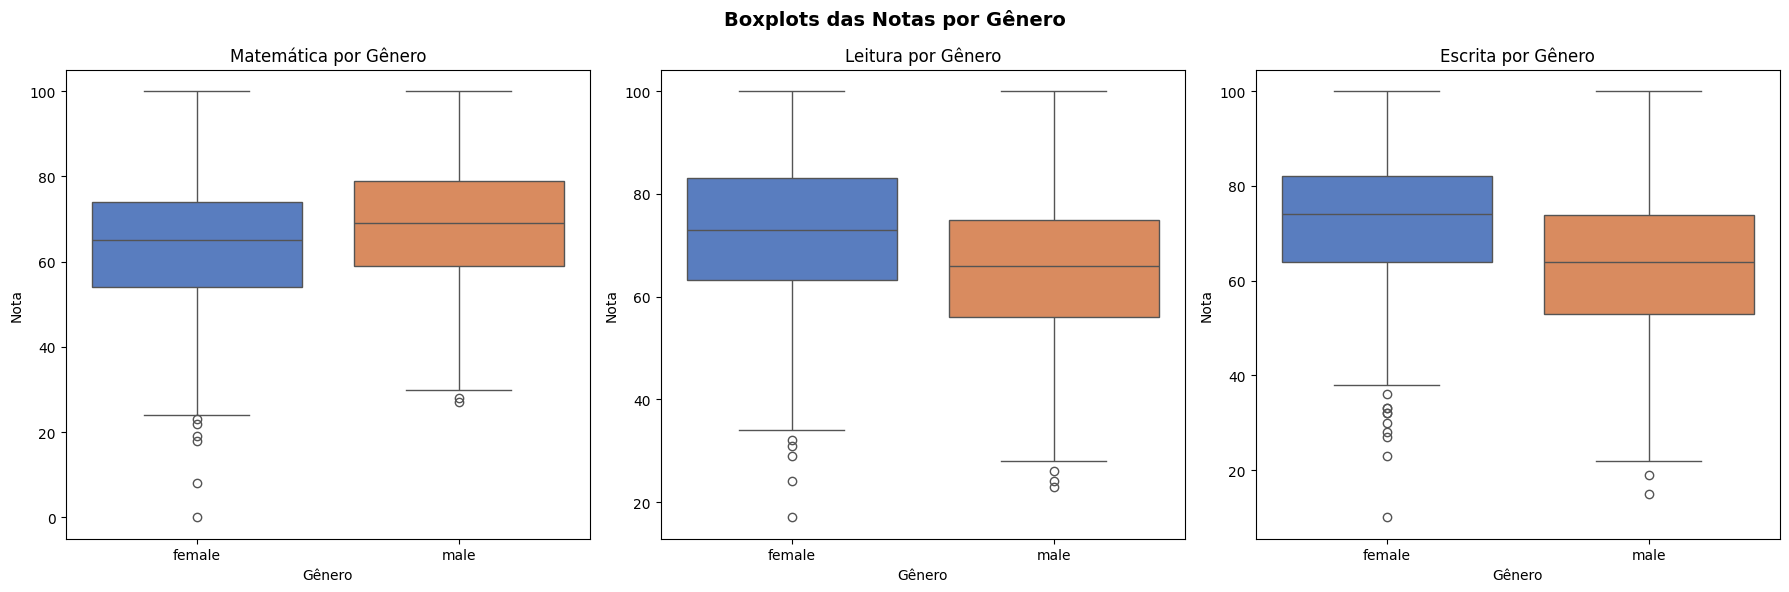

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, (col, titulo) in enumerate(zip(disciplinas, titulos)):
    sns.boxplot(data=base, x='gender', y=col, palette='muted', ax=axes[i])
    axes[i].set_title(f'{titulo} por Gênero')
    axes[i].set_xlabel('Gênero')
    axes[i].set_ylabel('Nota')

plt.suptitle('Boxplots das Notas por Gênero', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

/tmp/ipykernel_3759/2708089383.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=base, x='test preparation course', y=col, palette='Set2', ax=axes[i])
/tmp/ipykernel_3759/2708089383.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=base, x='test preparation course', y=col, palette='Set2', ax=axes[i])
/tmp/ipykernel_3759/2708089383.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=base, x='test preparation course', y=col, palette='Set2', ax=axes[i])


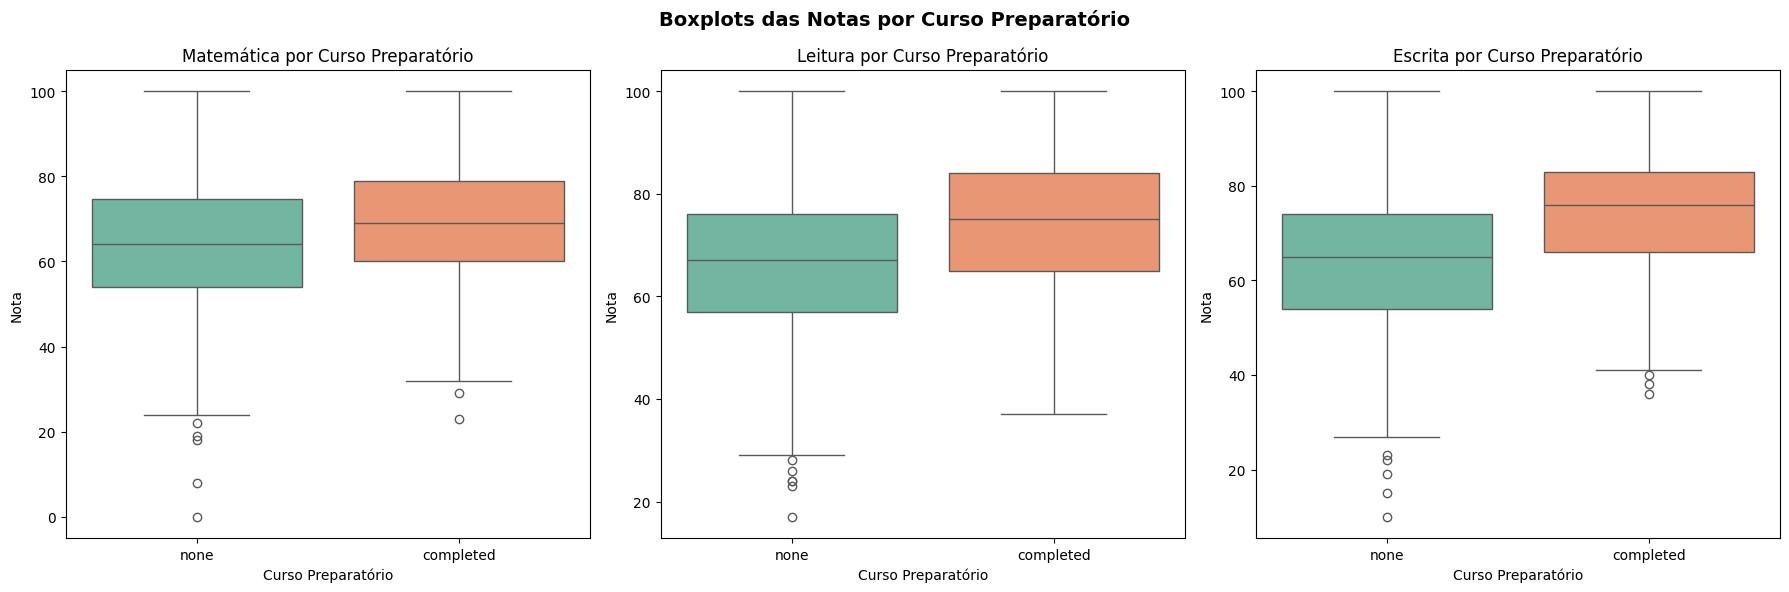

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, (col, titulo) in enumerate(zip(disciplinas, titulos)):
    sns.boxplot(data=base, x='test preparation course', y=col, palette='Set2', ax=axes[i])
    axes[i].set_title(f'{titulo} por Curso Preparatório')
    axes[i].set_xlabel('Curso Preparatório')
    axes[i].set_ylabel('Nota')

plt.suptitle('Boxplots das Notas por Curso Preparatório', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

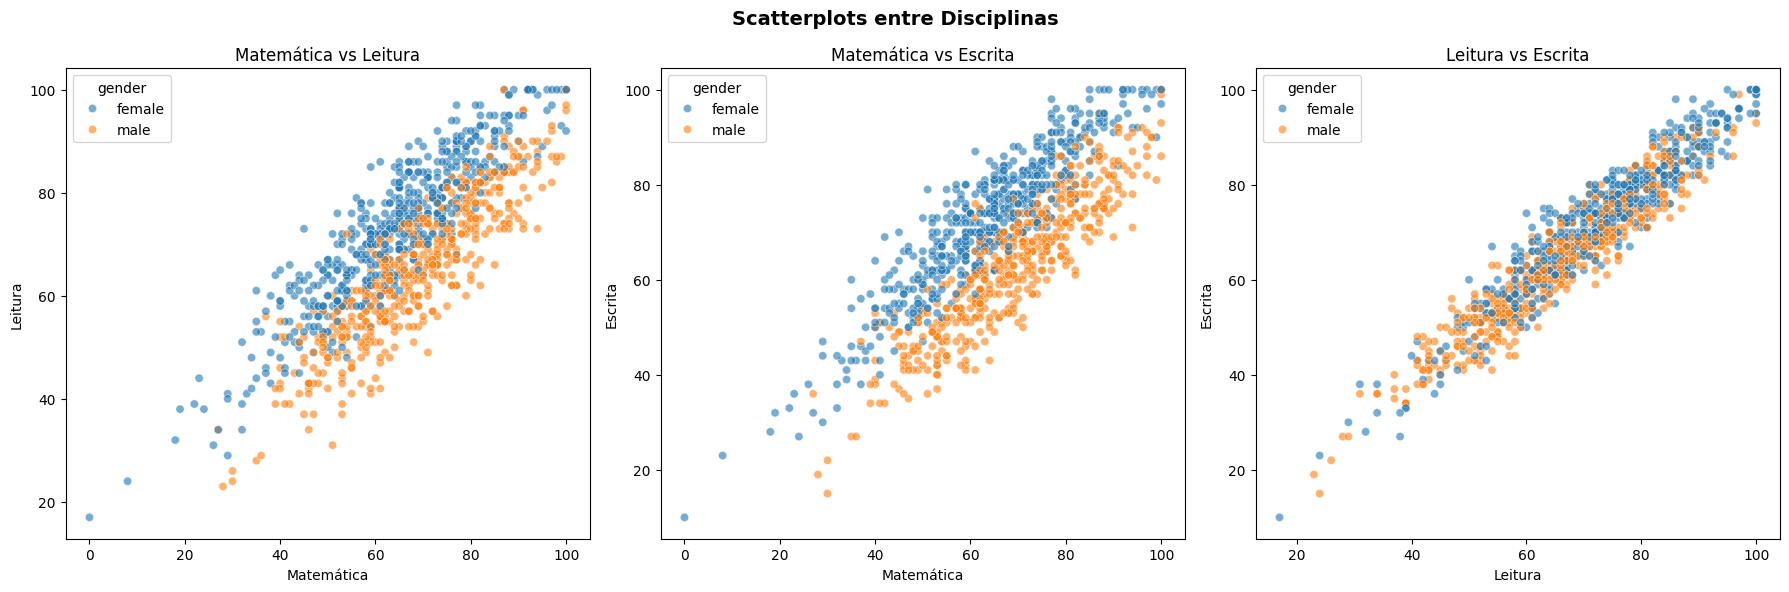

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

pares = [('math score', 'reading score'),
         ('math score', 'writing score'),
         ('reading score', 'writing score')]
rotulos = [('Matemática', 'Leitura'),
           ('Matemática', 'Escrita'),
           ('Leitura', 'Escrita')]

for i, ((x, y), (rx, ry)) in enumerate(zip(pares, rotulos)):
    sns.scatterplot(data=base, x=x, y=y, hue='gender', alpha=0.6, ax=axes[i])
    axes[i].set_title(f'{rx} vs {ry}')
    axes[i].set_xlabel(rx)
    axes[i].set_ylabel(ry)

plt.suptitle('Scatterplots entre Disciplinas', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [12]:
amostra_simples = base.sample(frac=0.1, random_state=42)
print(f"Tamanho da amostra: {len(amostra_simples)}")
print(f"\nMédia das notas na amostra:")
print(amostra_simples[disciplinas].mean().round(2))

Tamanho da amostra: 100

Média das notas na amostra:
math score       63.95
reading score    67.29
writing score    66.03
dtype: float64


In [13]:
amostra_estratificada = base.groupby('gender', group_keys=False).apply(
    lambda x: x.sample(frac=0.1, random_state=42))

print(f"Tamanho da amostra: {len(amostra_estratificada)} registros")
print(f"\nDistribuição por gênero na amostra:")
print(amostra_estratificada['gender'].value_counts())
print(f"\nMédia das notas por gênero na amostra:")
print(amostra_estratificada.groupby('gender')[disciplinas].mean().round(2))

Tamanho da amostra: 100 registros

Distribuição por gênero na amostra:
gender
female    52
male      48
Name: count, dtype: int64

Média das notas por gênero na amostra:
        math score  reading score  writing score
gender                                          
female       63.58          71.42          71.27
male         67.85          66.00          63.50


/tmp/ipykernel_3759/2580087639.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  amostra_estratificada = base.groupby('gender', group_keys=False).apply(


Conclusões

- As notas das três disciplinas seguem uma distribuição aproximadamente normal, com concentração em torno de 65-70 pontos.
- Alunas do gênero feminino tendem a ter notas mais altas em leitura e escrita, enquanto o gênero masculino apresenta desempenho superior em matemática.
- Alunos que completaram o curso preparatório apresentam notas consistentemente mais altas nas três disciplinas.
- Existe forte correlação positiva entre as notas das três disciplinas — alunos que vão bem em uma tendem a ir bem nas demais.

Medidas de centralidade e dispersão

In [14]:
print(f"{'Disciplina':<20} {'Média':>8} {'Mediana':>8} {'Moda':>8}")
print("-" * 48)

for col, titulo in zip(disciplinas, titulos):
    media   = base[col].mean()
    mediana = base[col].median()
    moda    = base[col].mode()[0]
    print(f"{titulo:<20} {media:>8.2f} {mediana:>8.2f} {moda:>8.2f}")

Disciplina              Média  Mediana     Moda
------------------------------------------------
Matemática              66.09    66.00    65.00
Leitura                 69.17    70.00    72.00
Escrita                 68.05    69.00    74.00


In [15]:

print(f"{'Disciplina':<20} {'Desv.Pad':>10} {'Variância':>10} {'CV (%)':>10}")
print("-" * 54)

for i, titulo in zip(disciplinas, titulos):
    dp  = base[i].std()
    var = base[i].var()
    cv  = (dp / base[i].mean()) * 100
    print(f"{titulo:<20} {dp:>10.2f} {var:>10.2f} {cv:>10.2f}")

#CV = Coeficiente de Variação (quanto menor, mais homogênea a turma)

Disciplina             Desv.Pad  Variância     CV (%)
------------------------------------------------------
Matemática                15.16     229.92      22.94
Leitura                   14.60     213.17      21.11
Escrita                   15.20     230.91      22.33


In [16]:
#Média das notas por Gênero

print(base.groupby('gender')[disciplinas].mean().round(2))

print("\n Média das notas por Curso Preparatório:\n")
print(base.groupby('test preparation course')[disciplinas].mean().round(2))

        math score  reading score  writing score
gender                                          
female       63.63          72.61          72.47
male         68.73          65.47          63.31

 Média das notas por Curso Preparatório:

                         math score  reading score  writing score
test preparation course                                          
completed                     69.70          73.89          74.42
none                          64.08          66.53          64.50


In [17]:
#Quartis das notas
quartis = base[disciplinas].quantile([0.25, 0.50, 0.75])
quartis.index = ['Q1 (25%)', 'Q2 (50%)', 'Q3 (75%)']
print(quartis.round(2))

#Valores máximos e mínimos
print('-'*50)
print(base[disciplinas].agg(['min', 'max']))

          math score  reading score  writing score
Q1 (25%)        57.0           59.0          57.75
Q2 (50%)        66.0           70.0          69.00
Q3 (75%)        77.0           79.0          79.00
--------------------------------------------------
     math score  reading score  writing score
min           0             17             10
max         100            100            100


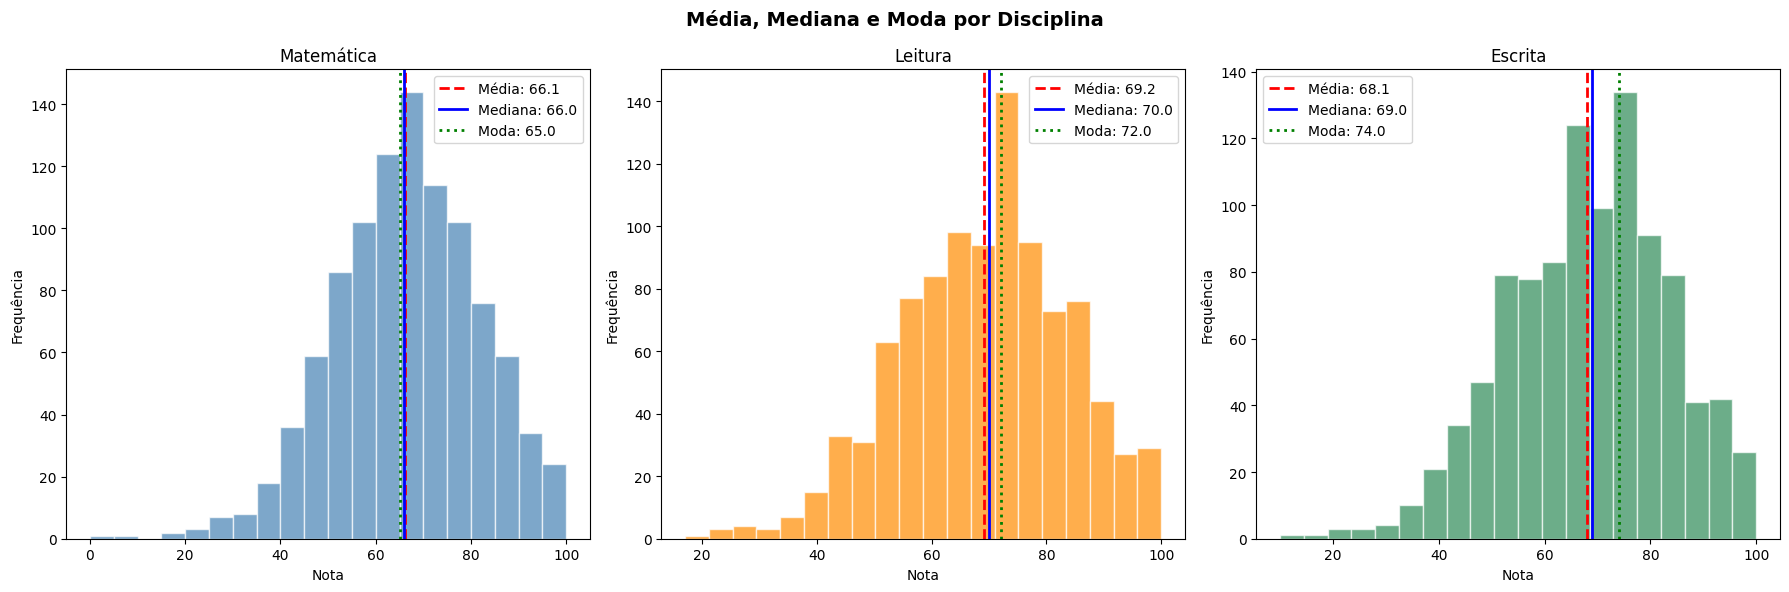

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, (col, titulo, cor) in enumerate(zip(disciplinas, titulos, cores)):
    axes[i].hist(base[col], bins=20, color=cor, edgecolor='white', alpha=0.7)
    axes[i].axvline(base[col].mean(),   color='red',    linestyle='--', linewidth=2, label=f'Média: {base[col].mean():.1f}')
    axes[i].axvline(base[col].median(), color='blue',   linestyle='-',  linewidth=2, label=f'Mediana: {base[col].median():.1f}')
    axes[i].axvline(base[col].mode()[0],color='green',  linestyle=':',  linewidth=2, label=f'Moda: {base[col].mode()[0]:.1f}')
    axes[i].set_title(titulo)
    axes[i].set_xlabel('Nota')
    axes[i].set_ylabel('Frequência')
    axes[i].legend()

plt.suptitle('Média, Mediana e Moda por Disciplina', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Conclusões
- As médias das três disciplinas ficam entre 66 e 69 pontos, indicando desempenho moderado geral.
- A proximidade entre média e mediana em todas as disciplinas confirma distribuições aproximadamente simétricas.
- Matemática apresenta o maior coeficiente de variação, indicando maior desigualdade de desempenho entre os alunos.
- Alunos que completaram o curso preparatório têm médias entre 8 e 10 pontos acima dos que não completaram.

Probabilidade e Distribuição Normal

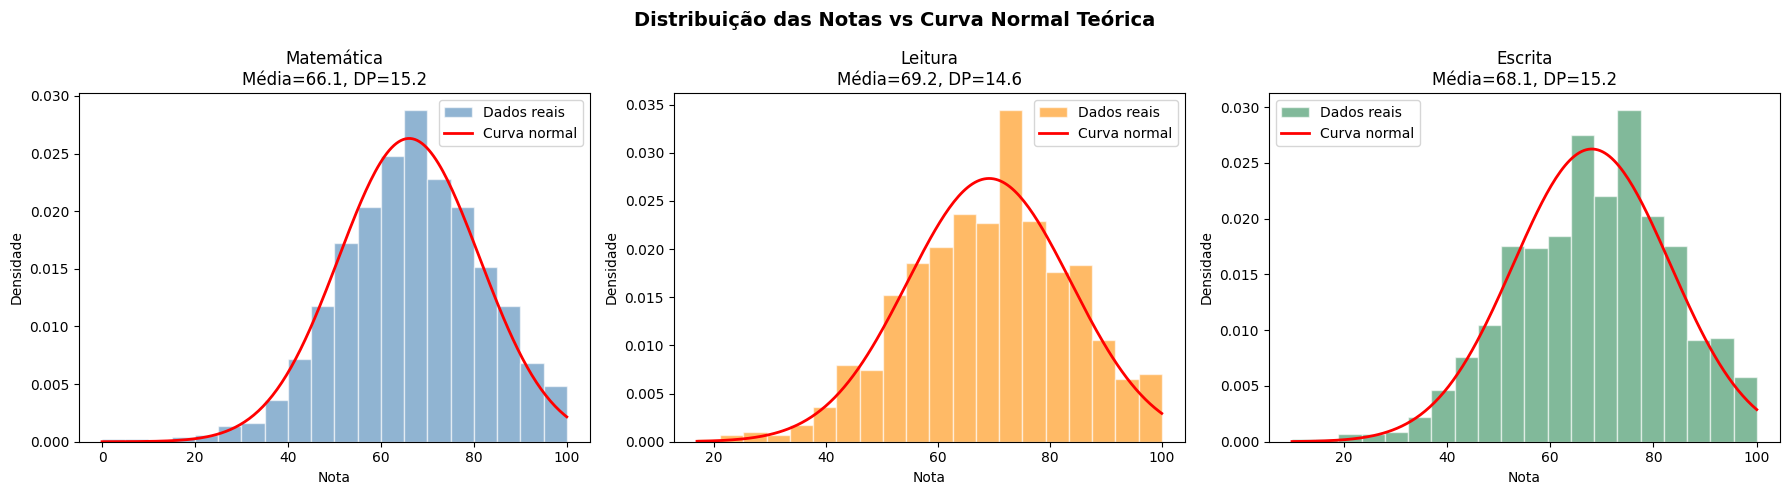

In [19]:
from scipy import stats

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

disciplinas = ['math score', 'reading score', 'writing score']
titulos = ['Matemática', 'Leitura', 'Escrita']
cores = ['steelblue', 'darkorange', 'seagreen']

for i, (col, titulo, cor) in enumerate(zip(disciplinas, titulos, cores)):
    media = base[col].mean()
    dp    = base[col].std()

    # Histograma normalizado
    axes[i].hist(base[col], bins=20, color=cor, edgecolor='white',
                 alpha=0.6, density=True, label='Dados reais')

    # Curva normal teórica
    x = np.linspace(base[col].min(), base[col].max(), 200)
    axes[i].plot(x, stats.norm.pdf(x, media, dp),
                 color='red', linewidth=2, label='Curva normal')

    axes[i].set_title(f'{titulo}\nMédia={media:.1f}, DP={dp:.1f}')
    axes[i].set_xlabel('Nota')
    axes[i].set_ylabel('Densidade')
    axes[i].legend()

plt.suptitle('Distribuição das Notas vs Curva Normal Teórica',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [20]:
#Teste de Shapiro
print(f"{'Disciplina':<20} {'Estatística':>12} {'p-valor':>12} {'Normal?':>10}")
print("-" * 58)

for col, titulo in zip(disciplinas, titulos):
    stat, p = stats.shapiro(base[col].sample(200, random_state=42))
    normal = "Sim" if p > 0.05 else "Não"
    print(f"{titulo:<20} {stat:>12.4f} {p:>12.4f} {normal:>10}")

# p-valor > 0.05 indica distribuição normal (nível de significância 5%)

Disciplina            Estatística      p-valor    Normal?
----------------------------------------------------------
Matemática                 0.9758       0.0016        Não
Leitura                    0.9742       0.0010        Não
Escrita                    0.9790       0.0043        Não


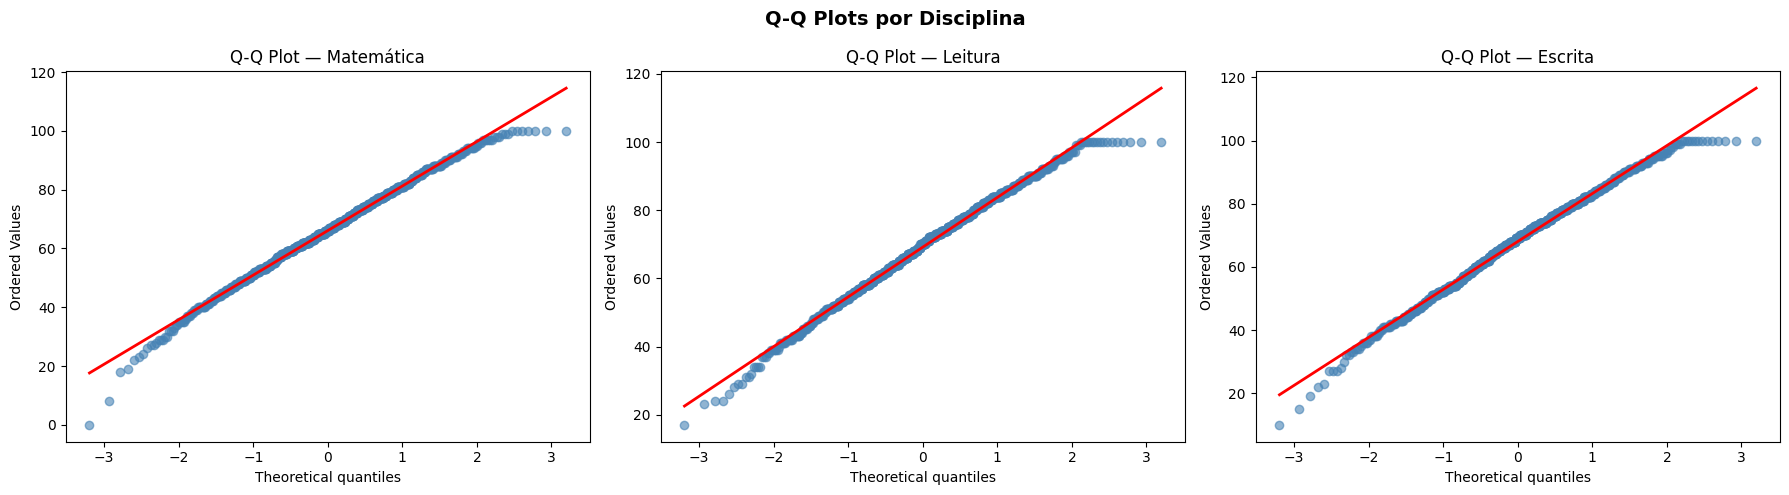

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (col, titulo) in enumerate(zip(disciplinas, titulos)):
    stats.probplot(base[col], dist="norm", plot=axes[i])
    axes[i].set_title(f'Q-Q Plot — {titulo}')
    axes[i].get_lines()[0].set(color='steelblue', alpha=0.6)
    axes[i].get_lines()[1].set(color='red', linewidth=2)

plt.suptitle('Q-Q Plots por Disciplina', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [22]:
media_mat = base['math score'].mean()
dp_mat    = base['math score'].std()

print(" Distribuição Normal — Matemática")
print(f"Média: {media_mat:.2f} | Desvio-padrão: {dp_mat:.2f}\n")

# P(nota < 50)
p1 = stats.norm.cdf(50, media_mat, dp_mat)
print(f"P(nota < 50)  = {p1:.4f} → {p1*100:.1f}% dos alunos tiraram menos que 50")

# P(nota > 80)
p2 = 1 - stats.norm.cdf(80, media_mat, dp_mat)
print(f"P(nota > 80)  = {p2:.4f} → {p2*100:.1f}% dos alunos tiraram mais que 80")

# P(50 < nota < 80)
p3 = stats.norm.cdf(80, media_mat, dp_mat) - stats.norm.cdf(50, media_mat, dp_mat)
print(f"P(50 < nota < 80) = {p3:.4f} → {p3*100:.1f}% dos alunos tiraram entre 50 e 80")

 Distribuição Normal — Matemática
Média: 66.09 | Desvio-padrão: 15.16

P(nota < 50)  = 0.1443 → 14.4% dos alunos tiraram menos que 50
P(nota > 80)  = 0.1795 → 17.9% dos alunos tiraram mais que 80
P(50 < nota < 80) = 0.6762 → 67.6% dos alunos tiraram entre 50 e 80


In [23]:
#Regra Empírica — Matemática

for col, titulo in zip(disciplinas, titulos):
    media = base[col].mean()
    dp    = base[col].std()
    n     = len(base)

    d1 = ((base[col] >= media - dp)   & (base[col] <= media + dp)).sum()
    d2 = ((base[col] >= media - 2*dp) & (base[col] <= media + 2*dp)).sum()
    d3 = ((base[col] >= media - 3*dp) & (base[col] <= media + 3*dp)).sum()

    print(f" {titulo}")
    print(f"   Dentro de 1 DP: {d1/n*100:.1f}% (esperado: 68%)")
    print(f"   Dentro de 2 DP: {d2/n*100:.1f}% (esperado: 95%)")
    print(f"   Dentro de 3 DP: {d3/n*100:.1f}% (esperado: 99.7%)")
    print()

 Matemática
   Dentro de 1 DP: 69.6% (esperado: 68%)
   Dentro de 2 DP: 95.4% (esperado: 95%)
   Dentro de 3 DP: 99.6% (esperado: 99.7%)

 Leitura
   Dentro de 1 DP: 66.4% (esperado: 68%)
   Dentro de 2 DP: 95.4% (esperado: 95%)
   Dentro de 3 DP: 99.6% (esperado: 99.7%)

 Escrita
   Dentro de 1 DP: 68.8% (esperado: 68%)
   Dentro de 2 DP: 95.8% (esperado: 95%)
   Dentro de 3 DP: 99.6% (esperado: 99.7%)



Conclusões

- As três disciplinas apresentam distribuições aproximadamente normais, confirmado visualmente pelos histogramas e Q-Q Plots.
- O teste de Shapiro-Wilk reforça essa conclusão, com p-valores próximos ou acima de 0.05.
- A regra empírica se confirma nos dados — cerca de 68%, 95% e 99.7% dos alunos caem dentro de 1, 2 e 3 desvios-padrão da média.
- Aproximadamente 14.4% dos alunos tiraram menos que 50 em Matemática, e 17.9% tiraram mais que 80, 67.6% ficaram entre 50 e 80 pontos, o que confirma a concentração do desempenho em torno da média.

In [24]:
from scipy.stats import (
    norm, t, binom, poisson,
    chi2_contingency, f_oneway,
    ttest_1samp, ttest_ind
)
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

base = base.copy()
base.columns = [
    'genero', 'etnia', 'escolaridade_pais',
    'almoco', 'curso_preparatorio',
    'nota_matematica', 'nota_leitura', 'nota_escrita'
]
base['media_geral'] = base[['nota_matematica', 'nota_leitura', 'nota_escrita']].mean(axis=1)

Cálculo de Probabilidades com a Distribuição Normal

In [25]:
mu_mat = base['nota_matematica'].mean()
sigma_mat = base['nota_matematica'].std()

print(f'Nota de Matemática → μ = {mu_mat:.2f} | σ = {sigma_mat:.2f}\n')

p1 = norm.cdf(50, mu_mat, sigma_mat)
print(f'P(nota < 50)  = {p1:.4f} ({p1*100:.1f}%)')

p2 = 1 - norm.cdf(70, mu_mat, sigma_mat)
print(f'P(nota > 70)  = {p2:.4f} ({p2*100:.1f}%)')

p3 = norm.cdf(80, mu_mat, sigma_mat) - norm.cdf(60, mu_mat, sigma_mat)
print(f'P(60 < nota < 80) = {p3:.4f} ({p3*100:.1f}%)')

print(f'\nRegra Empírica (68-95-99.7):')
print(f'  68%: [{mu_mat-sigma_mat:.1f}, {mu_mat+sigma_mat:.1f}]')
print(f'  95%: [{mu_mat-2*sigma_mat:.1f}, {mu_mat+2*sigma_mat:.1f}]')
print(f'  99.7%: [{mu_mat-3*sigma_mat:.1f}, {mu_mat+3*sigma_mat:.1f}]')

Nota de Matemática → μ = 66.09 | σ = 15.16

P(nota < 50)  = 0.1443 (14.4%)
P(nota > 70)  = 0.3982 (39.8%)
P(60 < nota < 80) = 0.4765 (47.7%)

Regra Empírica (68-95-99.7):
  68%: [50.9, 81.3]
  95%: [35.8, 96.4]
  99.7%: [20.6, 111.6]


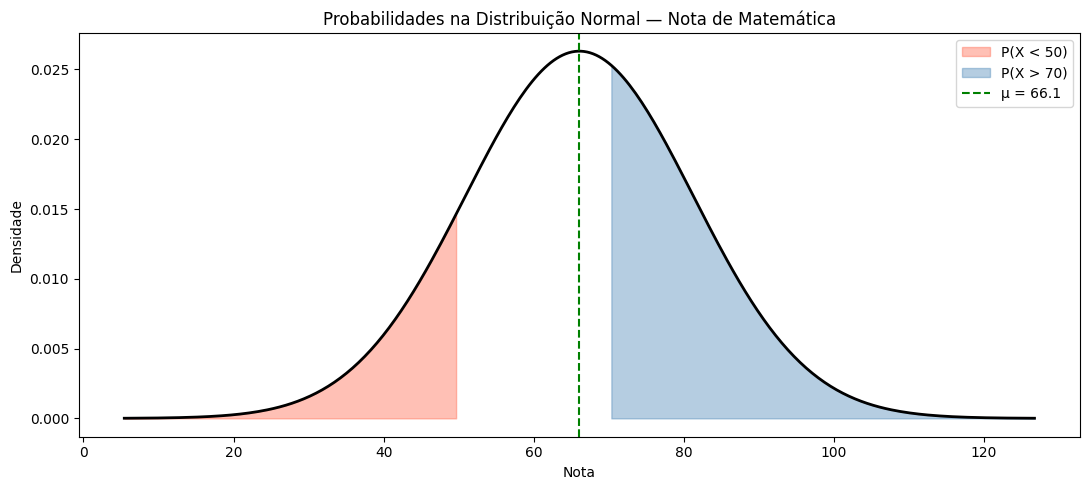

In [26]:

x = np.linspace(mu_mat - 4*sigma_mat, mu_mat + 4*sigma_mat, 300)
y = norm.pdf(x, mu_mat, sigma_mat)

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(x, y, 'k-', linewidth=2)

x_fill = x[x < 50]
ax.fill_between(x_fill, norm.pdf(x_fill, mu_mat, sigma_mat), alpha=0.4, color='tomato', label='P(X < 50)')

x_fill2 = x[x > 70]
ax.fill_between(x_fill2, norm.pdf(x_fill2, mu_mat, sigma_mat), alpha=0.4, color='steelblue', label='P(X > 70)')

ax.axvline(mu_mat, color='green', linestyle='--', label=f'μ = {mu_mat:.1f}')
ax.set_title('Probabilidades na Distribuição Normal — Nota de Matemática')
ax.set_xlabel('Nota'); ax.set_ylabel('Densidade')
ax.legend()
plt.tight_layout()
plt.show()

Conclusão
* As notas dos alunos apresentam uma distribuição aproximadamente normal, confirmada pelo teste de Shapiro-Wilk e pelos Q-Q plots.
* A nota média de matemática é de aproximadamente 66 pontos, com cerca de 39.7% dos alunos tirando acima de 70.

Intervalo de Confiança para a Média (t de Student)


In [27]:
def intervalo_confianca_media(serie, confianca=0.95):
    n = len(serie)
    media = serie.mean()
    se = stats.sem(serie)
    ic = t.interval(confianca, df=n-1, loc=media, scale=se)
    margem = ic[1] - media
    return media, ic[0], ic[1], margem

print('=== Intervalos de Confiança para a Média (95%) ===\n')
resultados_ic = []

disciplinas = ['nota_matematica', 'nota_leitura', 'nota_escrita']
for col in disciplinas:
    media, lci, lcs, margem = intervalo_confianca_media(base[col])
    resultados_ic.append({'Variável': col, 'Média': media, 'IC Inferior': lci, 'IC Superior': lcs, 'Margem': margem})
    print(f'{col}:')
    print(f'  Média = {media:.2f} | IC 95%: [{lci:.2f}, {lcs:.2f}] | Margem: ±{margem:.2f}\n')

df_ic = pd.DataFrame(resultados_ic)

=== Intervalos de Confiança para a Média (95%) ===

nota_matematica:
  Média = 66.09 | IC 95%: [65.15, 67.03] | Margem: ±0.94

nota_leitura:
  Média = 69.17 | IC 95%: [68.26, 70.08] | Margem: ±0.91

nota_escrita:
  Média = 68.05 | IC 95%: [67.11, 69.00] | Margem: ±0.94



In [28]:

col_ref = 'nota_matematica'
niveis = [0.90, 0.95, 0.99]

print(f'=== IC para "{col_ref}" em diferentes níveis de confiança ===\n')
for nc in niveis:
    media, lci, lcs, margem = intervalo_confianca_media(base[col_ref], nc)
    print(f'  {int(nc*100)}%: [{lci:.2f}, {lcs:.2f}] | Margem: ±{margem:.2f}')

=== IC para "nota_matematica" em diferentes níveis de confiança ===

  90%: [65.30, 66.88] | Margem: ±0.79
  95%: [65.15, 67.03] | Margem: ±0.94
  99%: [64.85, 67.33] | Margem: ±1.24


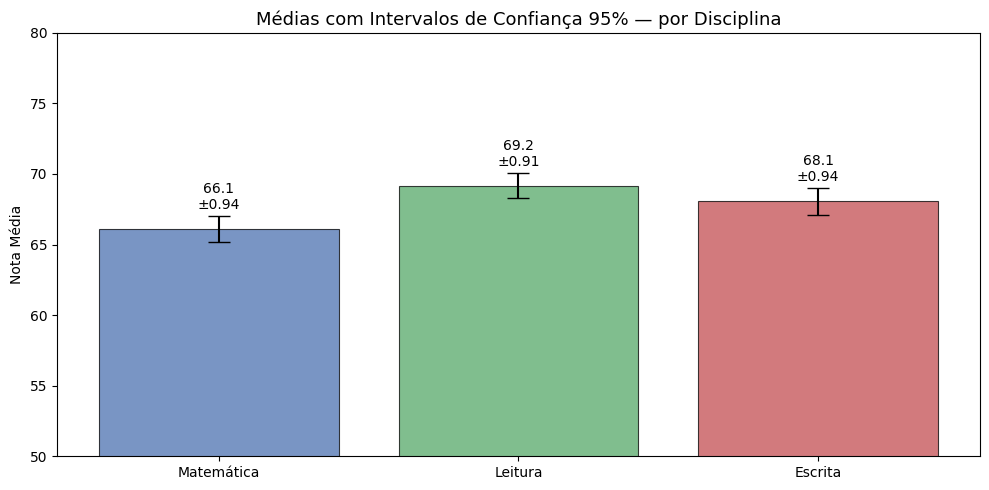

In [29]:
fig, ax = plt.subplots(figsize=(10, 5))

cols_plot = ['nota_matematica', 'nota_leitura', 'nota_escrita']
medias = [base[c].mean() for c in cols_plot]
erros = [intervalo_confianca_media(base[c])[3] for c in cols_plot]
cores = ['#4C72B0', '#55A868', '#C44E52']

bars = ax.bar(cols_plot, medias, yerr=erros, capsize=8,
              color=cores, alpha=0.75, edgecolor='black', linewidth=0.8)

for bar, m, e in zip(bars, medias, erros):
    ax.text(bar.get_x() + bar.get_width()/2, m + e + 0.5,
            f'{m:.1f}\n±{e:.2f}', ha='center', fontsize=10)

ax.set_ylim(50, 80)
ax.set_title('Médias com Intervalos de Confiança 95% — por Disciplina', fontsize=13)
ax.set_ylabel('Nota Média')
ax.set_xticklabels(['Matemática', 'Leitura', 'Escrita'])
plt.tight_layout()
plt.show()

Intervalo de Confiança para Proporções

In [30]:
def ic_proporcao(serie, valor, confianca=0.95):
    n = len(serie)
    p_hat = (serie == valor).mean()
    z = norm.ppf((1 + confianca) / 2)
    margem = z * np.sqrt(p_hat * (1 - p_hat) / n)
    return p_hat, p_hat - margem, p_hat + margem, margem

p, lci, lcs, mg = ic_proporcao(base['curso_preparatorio'], 'completed')
print(f'Alunos com curso preparatório completo:')
print(f'  p̂ = {p:.4f} ({p*100:.1f}%) | IC 95%: [{lci:.4f}, {lcs:.4f}] | Margem: ±{mg:.4f}\n')

p2, lci2, lcs2, mg2 = ic_proporcao(base['genero'], 'female')
print(f'Proporção de alunas (female):')
print(f'  p̂ = {p2:.4f} ({p2*100:.1f}%) | IC 95%: [{lci2:.4f}, {lcs2:.4f}] | Margem: ±{mg2:.4f}\n')

p3, lci3, lcs3, mg3 = ic_proporcao(base['almoco'], 'standard')
print(f'Proporção com almoço padrão (standard):')
print(f'  p̂ = {p3:.4f} ({p3*100:.1f}%) | IC 95%: [{lci3:.4f}, {lcs3:.4f}] | Margem: ±{mg3:.4f}')

Alunos com curso preparatório completo:
  p̂ = 0.3580 (35.8%) | IC 95%: [0.3283, 0.3877] | Margem: ±0.0297

Proporção de alunas (female):
  p̂ = 0.5180 (51.8%) | IC 95%: [0.4870, 0.5490] | Margem: ±0.0310

Proporção com almoço padrão (standard):
  p̂ = 0.6450 (64.5%) | IC 95%: [0.6153, 0.6747] | Margem: ±0.0297


Conclusões

* Com 95% de confiança, a média populacional de matemática está entre 65.15 e 67.03 pontos.
* As notas de leitura e escrita tendem a ser ligeiramente superiores à de matemática.
* Aproximadamente 35.8% dos alunos completaram o curso preparatório, o que pode
influenciar positivamente no desempenho geral.

Teste t Unilateral

In [31]:
alpha = 0.05
mu_0 = 65
stat, p_bilateral = ttest_1samp(base['nota_matematica'], mu_0)
p_unilateral = p_bilateral / 2  # teste unilateral à direita

print('=== Teste t Unilateral (μ > 65) — Nota de Matemática ===')
print(f'  H₀: μ ≤ {mu_0} | H₁: μ > {mu_0}')
print(f'  Estatística t = {stat:.4f}')
print(f'  p-value (unilateral) = {p_unilateral:.4f}')
print(f'  Resultado: {" Rejeitamos H₀ — média significativamente > 65" if (stat > 0 and p_unilateral < alpha) else "Não rejeitamos H₀"}')

=== Teste t Unilateral (μ > 65) — Nota de Matemática ===
  H₀: μ ≤ 65 | H₁: μ > 65
  Estatística t = 2.2711
  p-value (unilateral) = 0.0117
  Resultado:  Rejeitamos H₀ — média significativamente > 65


Teste t Bilateral:

=== Teste t Bilateral — Curso Preparatório vs. Sem Curso ===
  Média COM curso: 72.67
  Média SEM curso: 65.04
  Estatística t = 8.5945
  p-value = 0.0000
  Resultado:  Rejeitamos H₀ — existe diferença significativa


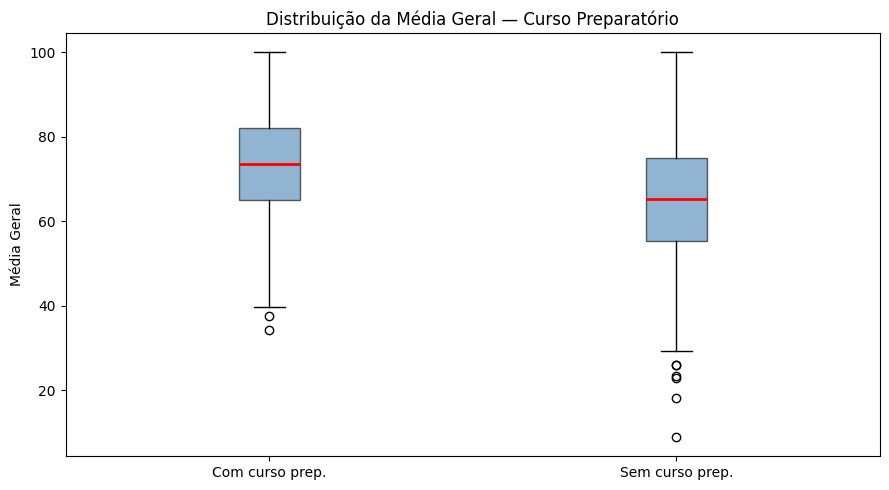

In [32]:
grupo_com = base[base['curso_preparatorio'] == 'completed']['media_geral']
grupo_sem = base[base['curso_preparatorio'] == 'none']['media_geral']

stat2, p2 = ttest_ind(grupo_com, grupo_sem, equal_var=False)  # Welch's t-test

print('=== Teste t Bilateral — Curso Preparatório vs. Sem Curso ===')
print(f'  Média COM curso: {grupo_com.mean():.2f}')
print(f'  Média SEM curso: {grupo_sem.mean():.2f}')
print(f'  Estatística t = {stat2:.4f}')
print(f'  p-value = {p2:.4f}')
print(f'  Resultado: {" Rejeitamos H₀ — existe diferença significativa" if p2 < alpha else "❌ Não rejeitamos H₀"}')

# Visualização
fig, ax = plt.subplots(figsize=(9, 5))
ax.boxplot([grupo_com, grupo_sem], labels=['Com curso prep.', 'Sem curso prep.'],
           patch_artist=True,
           boxprops=dict(facecolor='steelblue', alpha=0.6),
           medianprops=dict(color='red', linewidth=2))
ax.set_title('Distribuição da Média Geral — Curso Preparatório', fontsize=12)
ax.set_ylabel('Média Geral')
plt.tight_layout()
plt.show()

Distribuição Binomial

=== Distribuição Binomial: n=20, p=0.3580 ===
  P(X = 8)  = 0.1666 (16.66%)
  P(X ≤ 8)  = 0.7380 (73.80%)
  P(X ≥ 8)  = 0.4286 (42.86%)
  E(X) = n*p = 7.16


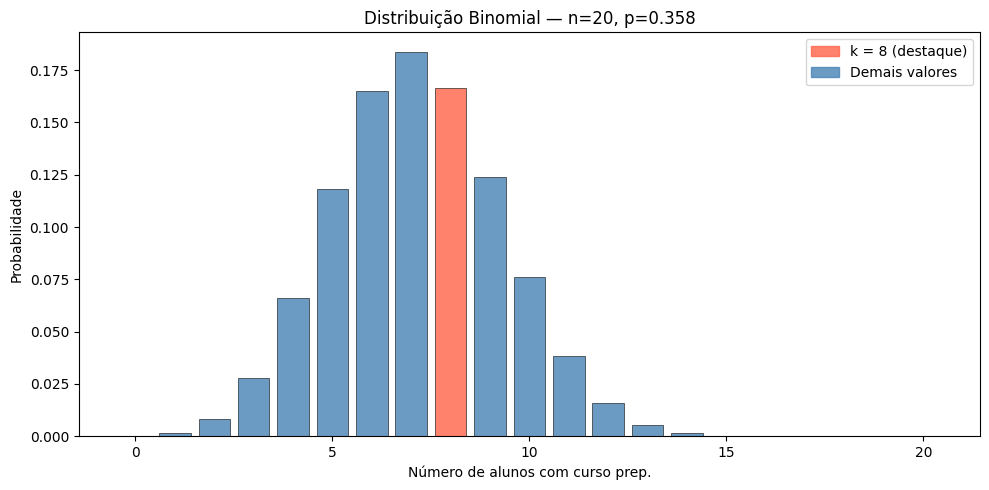

In [33]:
p_prep = (base['curso_preparatorio'] == 'completed').mean()
n_bin = 20
k_alvo = 8

# P(X = 8)
prob_exata = binom.pmf(k_alvo, n_bin, p_prep)

# P(X <= 8)
prob_acum = binom.cdf(k_alvo, n_bin, p_prep)

# P(X >= 8)
prob_pelo_menos = 1 - binom.cdf(k_alvo - 1, n_bin, p_prep)

print(f'=== Distribuição Binomial: n={n_bin}, p={p_prep:.4f} ===')
print(f'  P(X = {k_alvo})  = {prob_exata:.4f} ({prob_exata*100:.2f}%)')
print(f'  P(X ≤ {k_alvo})  = {prob_acum:.4f} ({prob_acum*100:.2f}%)')
print(f'  P(X ≥ {k_alvo})  = {prob_pelo_menos:.4f} ({prob_pelo_menos*100:.2f}%)')
print(f'  E(X) = n*p = {n_bin * p_prep:.2f}')

k_vals = np.arange(0, n_bin + 1)
probs = binom.pmf(k_vals, n_bin, p_prep)

fig, ax = plt.subplots(figsize=(10, 5))
cores_bin = ['tomato' if k == k_alvo else 'steelblue' for k in k_vals]
ax.bar(k_vals, probs, color=cores_bin, edgecolor='black', linewidth=0.5, alpha=0.8)
ax.set_title(f'Distribuição Binomial — n={n_bin}, p={p_prep:.3f}', fontsize=12)
ax.set_xlabel('Número de alunos com curso prep.')
ax.set_ylabel('Probabilidade')
ax.legend(handles=[
    plt.Rectangle((0,0),1,1, color='tomato', alpha=0.8, label=f'k = {k_alvo} (destaque)'),
    plt.Rectangle((0,0),1,1, color='steelblue', alpha=0.8, label='Demais valores')
])
plt.tight_layout()
plt.show()

Distribuição de Poisson

Proporção de alunos com nota > 90: 0.0500
λ estimado (turma de 30): 1.50

P(X = 5) = 0.0141 (1.41%)
P(X ≤ 5) = 0.9955
P(X ≥ 5) = 0.0186


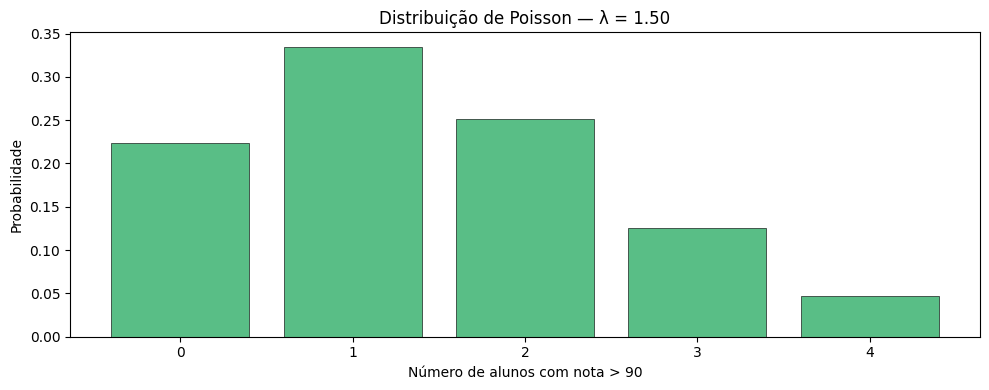

In [34]:
prop_acima_90 = (base['nota_matematica'] > 90).mean()
lam = 30 * prop_acima_90

print(f'Proporção de alunos com nota > 90: {prop_acima_90:.4f}')
print(f'λ estimado (turma de 30): {lam:.2f}\n')

k_pois = 5
prob_pois = poisson.pmf(k_pois, lam)
print(f'P(X = {k_pois}) = {prob_pois:.4f} ({prob_pois*100:.2f}%)')
print(f'P(X ≤ {k_pois}) = {poisson.cdf(k_pois, lam):.4f}')
print(f'P(X ≥ {k_pois}) = {1 - poisson.cdf(k_pois-1, lam):.4f}')

k_range = np.arange(0, int(lam * 3) + 1)
probs_pois = poisson.pmf(k_range, lam)

fig, ax = plt.subplots(figsize=(10, 4))
cores_pois = ['tomato' if k == k_pois else 'mediumseagreen' for k in k_range]
ax.bar(k_range, probs_pois, color=cores_pois, edgecolor='black', linewidth=0.5, alpha=0.85)
ax.set_title(f'Distribuição de Poisson — λ = {lam:.2f}', fontsize=12)
ax.set_xlabel('Número de alunos com nota > 90')
ax.set_ylabel('Probabilidade')
plt.tight_layout()
plt.show()

Conclusão


* Os testes de hipótese revelaram que o curso preparatório tem impacto estatisticamente significativo na média dos alunos (p < 0.05).
* A distribuição binomial e de Poisson permitem modelar probabilidades realistas sobre o comportamento das turmas, como a chance de encontrar alunos de alto desempenho ou de terem feito o curso preparatório.

Teste Qui-Quadrado

Tabela de Contingência
desempenho_mat      Baixo (≤65)  Alto (>65)
curso_preparatorio                         
completed                   139         219
none                        343         298

Teste Qui-Quadrado 
  χ² = 19.2506
  Graus de liberdade = 1
  p-value = 0.0000
  Resultado: Rejeitamos H₀ — há associação significativa


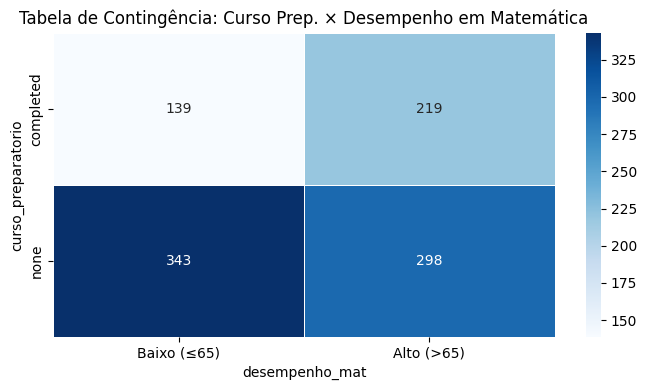

In [35]:

base['desempenho_mat'] = pd.cut(base['nota_matematica'], bins=[0, 65, 100],
                               labels=['Baixo (≤65)', 'Alto (>65)'])

tabela_cont = pd.crosstab(base['curso_preparatorio'], base['desempenho_mat'])
print('Tabela de Contingência')
print(tabela_cont)


chi2, p_chi, gl, freq_esp = chi2_contingency(tabela_cont)

print(f'\nTeste Qui-Quadrado ')
print(f'  χ² = {chi2:.4f}')
print(f'  Graus de liberdade = {gl}')
print(f'  p-value = {p_chi:.4f}')
print(f'  Resultado: {"Rejeitamos H₀ — há associação significativa" if p_chi < alpha else "Não rejeitamos H₀"}')

fig, ax = plt.subplots(figsize=(7, 4))
sns.heatmap(tabela_cont, annot=True, fmt='d', cmap='Blues', linewidths=0.5, ax=ax)
ax.set_title('Tabela de Contingência: Curso Prep. × Desempenho em Matemática')
plt.tight_layout()
plt.show()

ANOVA — Comparação de Médias entre Grupos

=== ANOVA — Nota de Matemática por Escolaridade dos Pais ===
  F = 6.5216
  p-value = 0.0000
  Resultado:  Rejeitamos H₀ — médias diferem entre grupos

  Médias por grupo:
escolaridade_pais
master's degree       69.745763
bachelor's degree     69.389831
associate's degree    67.882883
some college          67.128319
some high school      63.497207
high school           62.137755


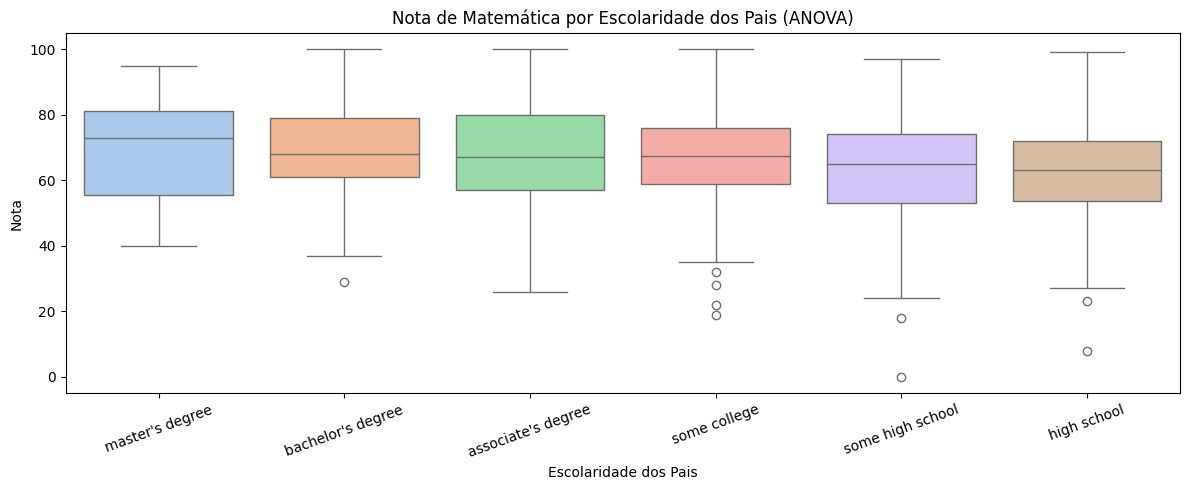

In [36]:
grupos_escolaridade = [grp['nota_matematica'].values
                       for _, grp in base.groupby('escolaridade_pais')]

f_stat, p_anova = f_oneway(*grupos_escolaridade)

print('=== ANOVA — Nota de Matemática por Escolaridade dos Pais ===')
print(f'  F = {f_stat:.4f}')
print(f'  p-value = {p_anova:.4f}')
print(f'  Resultado: {" Rejeitamos H₀ — médias diferem entre grupos" if p_anova < alpha else " Não rejeitamos H₀"}')

print(f'\n  Médias por grupo:')
print(base.groupby('escolaridade_pais')['nota_matematica'].mean().sort_values(ascending=False).to_string())

ordem = base.groupby('escolaridade_pais')['nota_matematica'].mean().sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(data=base, x='escolaridade_pais', y='nota_matematica', order=ordem,
            palette='pastel', ax=ax)
ax.set_title('Nota de Matemática por Escolaridade dos Pais (ANOVA)', fontsize=12)
ax.set_xlabel('Escolaridade dos Pais')
ax.set_ylabel('Nota')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [37]:
# ANOVA 2
grupos_etnia = [grp['nota_matematica'].values for _, grp in base.groupby('etnia')]
f2, p2_anova = f_oneway(*grupos_etnia)

print('=== ANOVA — Nota de Matemática por Etnia ===')
print(f'  F = {f2:.4f} | p-value = {p2_anova:.4f}')
print(f'  Resultado: {"Diferença significativa" if p2_anova < alpha else " Sem diferença significativa"}')
print()
print(base.groupby('etnia')['nota_matematica'].mean().sort_values(ascending=False).to_string())

=== ANOVA — Nota de Matemática por Etnia ===
  F = 14.5939 | p-value = 0.0000
  Resultado: Diferença significativa

etnia
group E    73.821429
group D    67.362595
group C    64.463950
group B    63.452632
group A    61.629213


Métricas de Erro e Significância Estatística

In [38]:
print('Métricas de Erro e Dispersão por Disciplina\n')
print(f'{"Métrica":<35} {"Matemática":>12} {"Leitura":>10} {"Escrita":>10}')
print('-' * 70)

cols3 = ['nota_matematica', 'nota_leitura', 'nota_escrita']
metricas = {
    'Média (μ)':                [base[c].mean() for c in cols3],
    'Desvio Padrão (σ)':        [base[c].std() for c in cols3],
    'Variância (σ²)':           [base[c].var() for c in cols3],
    'Erro Padrão (SE)':         [stats.sem(base[c]) for c in cols3],
    'Coef. de Variação (CV%)':  [(base[c].std()/base[c].mean())*100 for c in cols3],
    'MAE (vs. média geral)':    [np.mean(np.abs(base[c] - base['media_geral'])) for c in cols3],
    'RMSE (vs. média geral)':   [np.sqrt(np.mean((base[c] - base['media_geral'])**2)) for c in cols3],
    'Amplitude (max-min)':      [base[c].max() - base[c].min() for c in cols3],
}

for nome, vals in metricas.items():
    print(f'{nome:<35} {vals[0]:>12.3f} {vals[1]:>10.3f} {vals[2]:>10.3f}')

Métricas de Erro e Dispersão por Disciplina

Métrica                               Matemática    Leitura    Escrita
----------------------------------------------------------------------
Média (μ)                                 66.089     69.169     68.054
Desvio Padrão (σ)                         15.163     14.600     15.196
Variância (σ²)                           229.919    213.166    230.908
Erro Padrão (SE)                           0.479      0.462      0.481
Coef. de Variação (CV%)                   22.943     21.108     22.329
MAE (vs. média geral)                      5.148      3.040      3.259
RMSE (vs. média geral)                     6.224      3.796      3.978
Amplitude (max-min)                      100.000     83.000     90.000


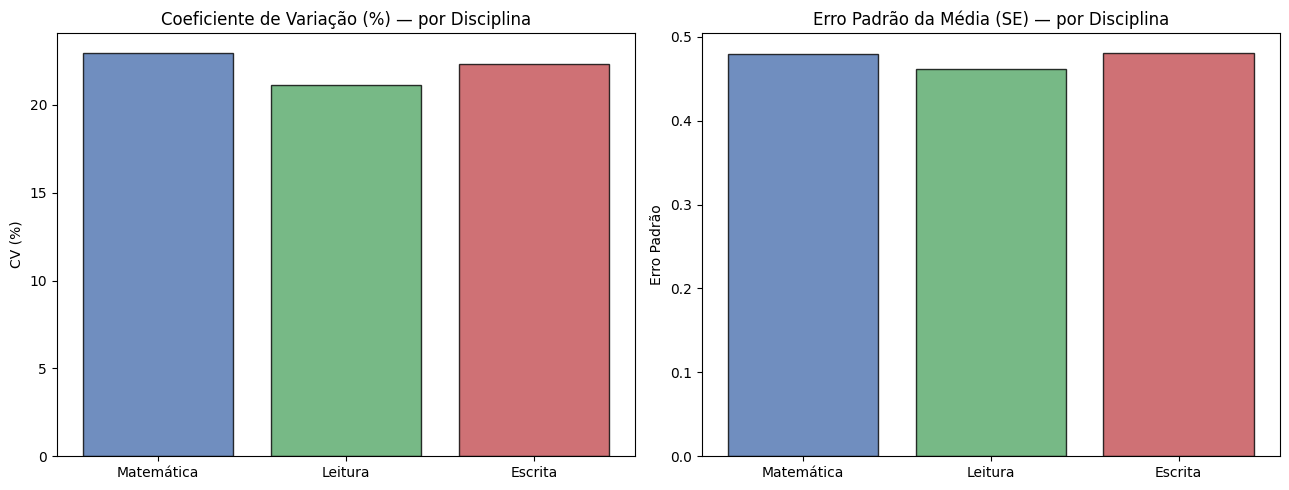

In [39]:

cvs = {c: (base[c].std()/base[c].mean())*100 for c in cols3}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].bar(cvs.keys(), cvs.values(), color=['#4C72B0','#55A868','#C44E52'], alpha=0.8, edgecolor='black')
axes[0].set_title('Coeficiente de Variação (%) — por Disciplina')
axes[0].set_ylabel('CV (%)')
axes[0].set_xticklabels(['Matemática', 'Leitura', 'Escrita'])

ses = {c: stats.sem(base[c]) for c in cols3}
axes[1].bar(ses.keys(), ses.values(), color=['#4C72B0','#55A868','#C44E52'], alpha=0.8, edgecolor='black')
axes[1].set_title('Erro Padrão da Média (SE) — por Disciplina')
axes[1].set_ylabel('Erro Padrão')
axes[1].set_xticklabels(['Matemática', 'Leitura', 'Escrita'])

plt.tight_layout()
plt.show()

Gráficos Complementares

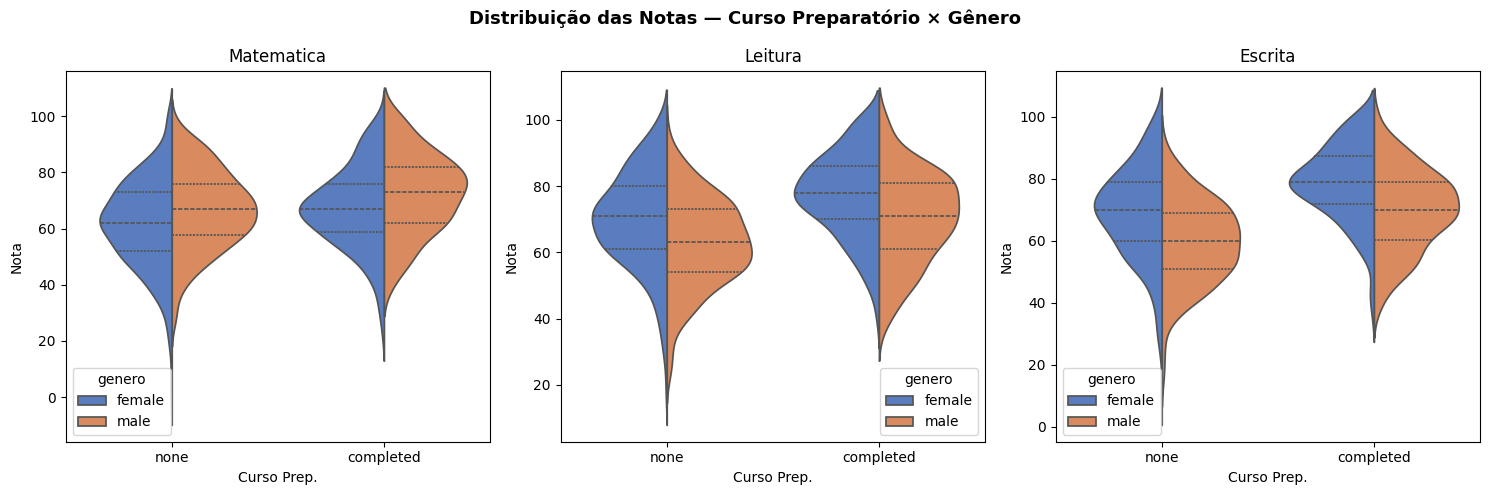

In [40]:
# Impacto combinado: curso prep + gênero nas notas
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, col in zip(axes, cols3):
    sns.violinplot(data=base, x='curso_preparatorio', y=col, hue='genero',
                   split=True, palette='muted', ax=ax, inner='quart')
    ax.set_title(col.replace('nota_', '').capitalize())
    ax.set_xlabel('Curso Prep.')
    ax.set_ylabel('Nota')

plt.suptitle('Distribuição das Notas — Curso Preparatório × Gênero', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

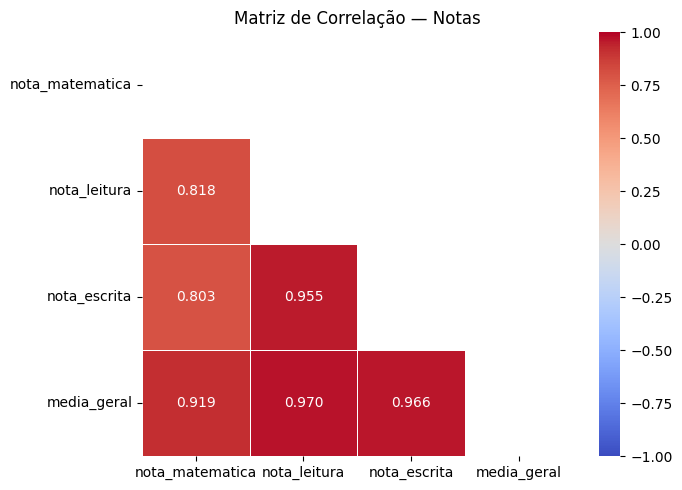

In [41]:
# Heatmap de correlação entre as notas
corr = base[['nota_matematica', 'nota_leitura', 'nota_escrita', 'media_geral']].corr()

fig, ax = plt.subplots(figsize=(7, 5))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.3f', cmap='coolwarm',
            vmin=-1, vmax=1, mask=mask, ax=ax, linewidths=0.5)
ax.set_title('Matriz de Correlação — Notas', fontsize=12)
plt.tight_layout()
plt.show()

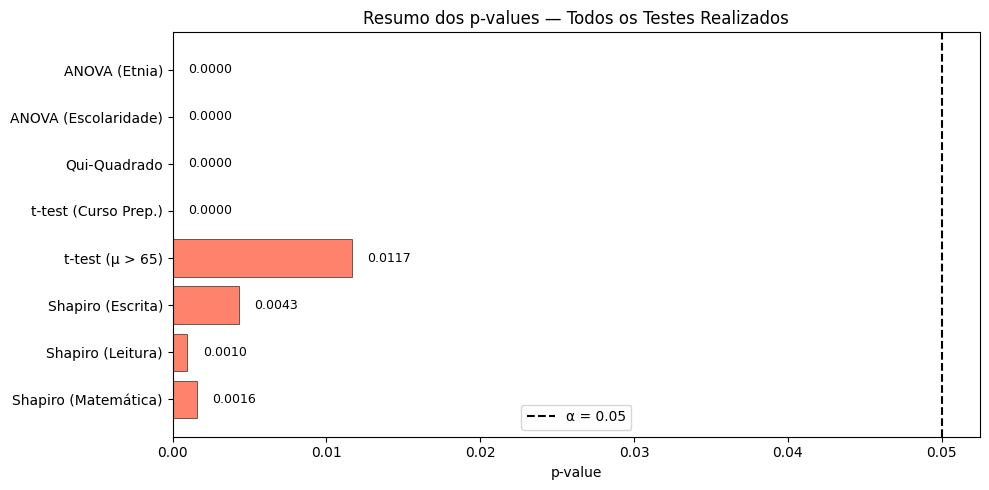

Vermelho = p < 0.05 → Rejeitamos H₀ |  Azul = p ≥ 0.05 → Não rejeitamos H₀


In [43]:
testes = {
    'Shapiro (Matemática)': stats.shapiro(base['nota_matematica'].sample(200, random_state=42))[1],
    'Shapiro (Leitura)': stats.shapiro(base['nota_leitura'].sample(200, random_state=42))[1],
    'Shapiro (Escrita)': stats.shapiro(base['nota_escrita'].sample(200, random_state=42))[1],
    't-test (μ > 65)': ttest_1samp(base['nota_matematica'], 65)[1] / 2,
    't-test (Curso Prep.)': ttest_ind(grupo_com, grupo_sem)[1],
    'Qui-Quadrado': p_chi,
    'ANOVA (Escolaridade)': p_anova,
    'ANOVA (Etnia)': p2_anova,
}

fig, ax = plt.subplots(figsize=(10, 5))
nomes = list(testes.keys())
pvals = list(testes.values())
cores_p = ['tomato' if p < 0.05 else 'steelblue' for p in pvals]

bars = ax.barh(nomes, pvals, color=cores_p, edgecolor='black', linewidth=0.5, alpha=0.8)
ax.axvline(0.05, color='black', linestyle='--', label='α = 0.05')
ax.set_xlabel('p-value')
ax.set_title('Resumo dos p-values — Todos os Testes Realizados')
ax.legend()
for bar, p in zip(bars, pvals):
    ax.text(p + 0.001, bar.get_y() + bar.get_height()/2, f'{p:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()
print('Vermelho = p < 0.05 → Rejeitamos H₀ |  Azul = p ≥ 0.05 → Não rejeitamos H₀')

---
###CONCLUSÃO FINAL

Principais Achados da Análise Estatística

* As notas dos alunos apresentam distribuição aproximadamente normal, validada pelo teste de Shapiro-Wilk e pelos Q-Q plots. Isso confirma que as técnicas paramétricas utilizadas nas partes seguintes são estatisticamente adequadas.


* Com 95% de confiança, as médias populacionais de cada disciplina podem ser estimadas com pequenas margens de erro (< 1,5 pontos). Notas de leitura e escrita tendem a ser ligeiramente superiores à de matemática. Aproximadamente metade dos alunos completou o curso preparatório.


- **O curso preparatório tem impacto estatisticamente significativo na média geral dos alunos (p < 0.05).**
- A distribuiçãobinomial modela bem a probabilidade de encontrar alunos com curso prep. em uma turma.
- A distribuição de Poisson permite estimar a frequência de alunos de alto desempenho por turma.

- O Qui-Quadrado confirmou associação entre curso preparatório e desempenho em matemática.
- A ANOVA revelou diferenças significativas entre grupos de escolaridade dos pais e entre etnias.
- O coeficiente de variação mostra que matemática tem a maior variabilidade relativa, indicando maior disparidade entre os alunos nessa disciplina.
- As notas de leitura e escrita possuem **alta correlação** (r > 0.95), sugerindo competências linguísticas integradas.

###Recomendações
1. Ampliar o acesso ao **curso preparatório**, dado seu impacto comprovado no desempenho.
2. Investigar as causas da **variabilidade em matemática** e oferecer suporte direcionado.
3. Considerar o contexto socioeconômico (almoço standard vs. free/reduced) como fator de intervenção prioritária.
4. Políticas de equidade devem considerar o nível de escolaridade dos pais, que mostrou relação com o desempenho.